# A Python-Based Workflow for Financial Ratio Analysis and Company Comparison (Track 2)

## Zihan.Li   2470788

---

## Project Overview
This project develops a reusable Python-based workflow to analyse and compare the financial performance of different companies using financial ratios. 

The analysis focuses on recent financial performance, using data from 2018 onwards to ensure consistency and comparability.

The workflow is designed to be reusable and can be applied to different companies by modifying input parameters.

---

## Analytical Problem
How can financial ratios be used to analyse and compare the performance of different companies in a simple and structured way?

---

## Method
This project uses Python to automate data retrieval, data processing, ratio calculation, visual comparison, and basic rule-based conclusions.

---

## Target User
The workflow is designed for beginner users who want a simple and structured way to analyse company performance using Python.

---

## Data Source and Scope
This project uses financial statement data from the WRDS Compustat database (`comp.funda`).

The workflow is primarily applicable to companies covered by Compustat (mainly US listed companies).The input tickers should correspond to companies available in the Compustat database.

---

## Note on Comparability
For meaningful comparison, it is generally recommended to select companies from the same industry, as financial ratios may vary significantly across industries.

However, this workflow does not restrict company selection, allowing users to explore different comparisons based on their needs.

---

## Demonstration

This workflow can be applied to any two companies covered by the Compustat database.

For demonstration purposes, users may enter PepsiCo (PEP) and Coca-Cola (KO) as example inputs to illustrate how the workflow works in practice.

---

## Step 1: Import packages and connect to WRDS

In this step, the required Python packages are imported and a connection to WRDS is established.

In [6]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt

# import your WRDS username
username = input("Enter your WRDS username: ")

# Connect to WRDS
db = wrds.Connection(wrds_username=username)

Enter your WRDS username:  lizzzz


Loading library list...
Done


## Step 2: User Input

In this step, the user is asked to input two company tickers for comparison.

The workflow then uses these inputs to retrieve financial data, calculate ratios, generate charts, and produce automated conclusions.

For demonstration purposes, PepsiCo (PEP) and Coca-Cola (KO) can be used as example inputs.

**Notice:** Users should enter **valid** company tickers available in the Compustat database. Invalid or inconsistent inputs may result in incomplete or missing data, which can affect analysis results.

In [7]:
# Ask the user to input two company tickers
company_1 = input("Please enter the first company ticker correctly: ").upper()
company_2 = input("Please enter the second company ticker correctly: ").upper()

tickers = [company_1, company_2]

# Define the start date for analysis
start_date = '2018-01-01'

# Convert the ticker list into a format suitable for SQL
ticker_str = "', '".join(tickers)

Please enter the first company ticker correctly:  KO
Please enter the second company ticker correctly:  PEP


## Step 3: Retrieve financial statement data from WRDS

This step retrieves annual financial statement data from the Compustat `funda` table for the selected companies.

The variables used in this project include:
- `sale`: sales/revenue
- `ni`: net income
- `at`: total assets
- `seq`: total equity

In [8]:
query = f"""
SELECT datadate, tic, sale, ni, at, seq
FROM comp.funda
WHERE tic IN ('{ticker_str}')
AND datadate >= '{start_date}'
"""

In [9]:
selected_data= db.raw_sql(query, date_cols=['datadate'])

In [10]:
# Check whether the data has been correctly retrieved.
selected_data.head(20)

#This step verifies that the data has been successfully retrieved.

,datadate,tic,sale,ni,at,seq
0,2018-12-31,KO,31856.0,6434.0,83216.0,16981.0
1,2018-12-31,KO,34300.0,6434.0,83216.0,16981.0
2,2019-12-31,KO,37266.0,8920.0,86381.0,18981.0
3,2019-12-31,KO,37266.0,8920.0,86381.0,18981.0
4,2020-12-31,KO,33014.0,7747.0,87296.0,19299.0
5,2020-12-31,KO,33014.0,7747.0,87296.0,19299.0
6,2021-12-31,KO,38655.0,9771.0,94354.0,22999.0
7,2021-12-31,KO,38655.0,9771.0,94354.0,22999.0
8,2022-12-31,KO,43004.0,9542.0,92763.0,24105.0
9,2022-12-31,KO,43004.0,9542.0,92763.0,24105.0


## Step 4: Data cleaning
The dataset contains duplicate rows for the same company and year. These duplicates may arise from multiple records in the database. Since the duplicated rows have identical values, they are removed to ensure clean and accurate analysis.

In [11]:
selected_data = selected_data.drop_duplicates()

print(selected_data)

     datadate  tic     sale       ni        at      seq
0  2018-12-31   KO  31856.0   6434.0   83216.0  16981.0
1  2018-12-31   KO  34300.0   6434.0   83216.0  16981.0
2  2019-12-31   KO  37266.0   8920.0   86381.0  18981.0
4  2020-12-31   KO  33014.0   7747.0   87296.0  19299.0
6  2021-12-31   KO  38655.0   9771.0   94354.0  22999.0
8  2022-12-31   KO  43004.0   9542.0   92763.0  24105.0
10 2023-12-31   KO  45754.0  10714.0   97703.0  25941.0
12 2024-12-31   KO  47061.0  10631.0  100549.0  24856.0
14 2025-12-31   KO  47941.0  13107.0  104816.0  32169.0
16 2018-12-31  PEP  64661.0  12515.0   77648.0  14518.0
18 2019-12-31  PEP  67161.0   7314.0   78547.0  14786.0
20 2020-12-31  PEP  70372.0   7120.0   92918.0  13454.0
22 2021-12-31  PEP  79474.0   7618.0   92377.0  16043.0
24 2022-12-31  PEP  86392.0   8910.0   92187.0  17149.0
26 2023-12-31  PEP  91471.0   9074.0  100495.0  18503.0
28 2024-12-31  PEP  91854.0   9578.0   99467.0  18041.0
30 2025-12-31  PEP  93925.0   8240.0  107399.0  

## Step 5: Rename Variables

The original variable names from the dataset are renamed to more intuitive names to improve readability and make the analysis easier to understand.

In [12]:
selected_data = selected_data.rename(columns={
    'tic': 'company',
    'sale': 'revenue',
    'ni': 'net_income',
    'at': 'total_assets',
    'seq': 'equity'
})

In [13]:
#check 

print(selected_data)

     datadate company  revenue  net_income  total_assets   equity
0  2018-12-31      KO  31856.0      6434.0       83216.0  16981.0
1  2018-12-31      KO  34300.0      6434.0       83216.0  16981.0
2  2019-12-31      KO  37266.0      8920.0       86381.0  18981.0
4  2020-12-31      KO  33014.0      7747.0       87296.0  19299.0
6  2021-12-31      KO  38655.0      9771.0       94354.0  22999.0
8  2022-12-31      KO  43004.0      9542.0       92763.0  24105.0
10 2023-12-31      KO  45754.0     10714.0       97703.0  25941.0
12 2024-12-31      KO  47061.0     10631.0      100549.0  24856.0
14 2025-12-31      KO  47941.0     13107.0      104816.0  32169.0
16 2018-12-31     PEP  64661.0     12515.0       77648.0  14518.0
18 2019-12-31     PEP  67161.0      7314.0       78547.0  14786.0
20 2020-12-31     PEP  70372.0      7120.0       92918.0  13454.0
22 2021-12-31     PEP  79474.0      7618.0       92377.0  16043.0
24 2022-12-31     PEP  86392.0      8910.0       92187.0  17149.0
26 2023-12

## Step 6: Calculate Financial Ratios

In this step, financial ratios are calculated to evaluate company performance.

### Return on Equity (ROE)
ROE measures how efficiently a company generates profit from shareholders' equity.

In [14]:
selected_data['ROE'] = selected_data['net_income'] / selected_data['equity']

In [15]:
selected_data.head()

,datadate,company,revenue,net_income,total_assets,equity,ROE
0,2018-12-31,KO,31856.0,6434.0,83216.0,16981.0,0.378894
1,2018-12-31,KO,34300.0,6434.0,83216.0,16981.0,0.378894
2,2019-12-31,KO,37266.0,8920.0,86381.0,18981.0,0.469944
4,2020-12-31,KO,33014.0,7747.0,87296.0,19299.0,0.40142
6,2021-12-31,KO,38655.0,9771.0,94354.0,22999.0,0.424845


### Profit Margin

Profit margin measures how much profit a company generates from its sales revenue.

It is calculated as net income divided by sales.

In [16]:
selected_data['profit_margin'] = selected_data['net_income'] / selected_data['revenue']

In [17]:
selected_data.head()

,datadate,company,revenue,net_income,total_assets,equity,ROE,profit_margin
0,2018-12-31,KO,31856.0,6434.0,83216.0,16981.0,0.378894,0.201971
1,2018-12-31,KO,34300.0,6434.0,83216.0,16981.0,0.378894,0.18758
2,2019-12-31,KO,37266.0,8920.0,86381.0,18981.0,0.469944,0.23936
4,2020-12-31,KO,33014.0,7747.0,87296.0,19299.0,0.40142,0.234658
6,2021-12-31,KO,38655.0,9771.0,94354.0,22999.0,0.424845,0.252775


### Asset Turnover

Asset turnover measures how efficiently a company uses its assets to generate sales.

It is calculated as sales divided by total assets.

In [18]:
selected_data['asset_turnover'] = selected_data['revenue'] / selected_data['total_assets']

In [19]:
selected_data.head()

,datadate,company,revenue,net_income,total_assets,equity,ROE,profit_margin,asset_turnover
0,2018-12-31,KO,31856.0,6434.0,83216.0,16981.0,0.378894,0.201971,0.382811
1,2018-12-31,KO,34300.0,6434.0,83216.0,16981.0,0.378894,0.18758,0.41218
2,2019-12-31,KO,37266.0,8920.0,86381.0,18981.0,0.469944,0.23936,0.431414
4,2020-12-31,KO,33014.0,7747.0,87296.0,19299.0,0.40142,0.234658,0.378185
6,2021-12-31,KO,38655.0,9771.0,94354.0,22999.0,0.424845,0.252775,0.409681


### Leverage

Leverage measures the extent to which a company uses external financing relative to equity.

In this project, leverage is calculated as total assets divided by equity.

In [20]:
selected_data['leverage'] = selected_data['total_assets'] / selected_data['equity']

In [21]:
selected_data.head()

,datadate,company,revenue,net_income,total_assets,equity,ROE,profit_margin,asset_turnover,leverage
0,2018-12-31,KO,31856.0,6434.0,83216.0,16981.0,0.378894,0.201971,0.382811,4.900536
1,2018-12-31,KO,34300.0,6434.0,83216.0,16981.0,0.378894,0.18758,0.41218,4.900536
2,2019-12-31,KO,37266.0,8920.0,86381.0,18981.0,0.469944,0.23936,0.431414,4.550919
4,2020-12-31,KO,33014.0,7747.0,87296.0,19299.0,0.40142,0.234658,0.378185,4.523343
6,2021-12-31,KO,38655.0,9771.0,94354.0,22999.0,0.424845,0.252775,0.409681,4.102526


These four financial ratios together provide a more comprehensive view of company performance:

- ROE reflects overall return to shareholders
- Profit margin reflects profitability
- Asset turnover reflects efficiency in using assets
- Leverage reflects the degree of financial leverage

Together, these ratios help explain not only how well a company performs, but also why performance differs across companies.

## Step 7: Visualise Financial Ratios

In this step, line charts are used to compare financial ratios across companies over time.

### ROE Comparison
The chart below compares the ROE of the selected companies over time.

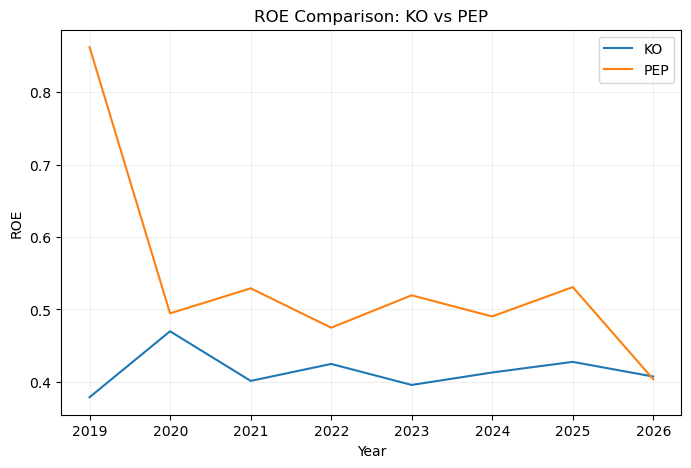

In [22]:
company_1_data = selected_data[selected_data['company'] == company_1]
company_2_data = selected_data[selected_data['company'] == company_2]

plt.figure(figsize=(8,5))

plt.plot(company_1_data['datadate'], company_1_data['ROE'], label=company_1)
plt.plot(company_2_data['datadate'], company_2_data['ROE'], label=company_2)

plt.title('ROE Comparison: ' + company_1 + ' vs ' + company_2)
plt.xlabel('Year')
plt.ylabel('ROE')
plt.legend()
plt.grid(alpha=0.2) 

plt.show()

### Interpretation of ROE

The chart shows the ROE of the two selected companies over time.

Differences in ROE indicate that the two companies generate different levels of return for shareholders.

The visual comparison helps users identify whether one company consistently performs better or whether performance changes over time.

### Profit Margin Comparison

The chart below compares the profit margin of the selected companies over time.

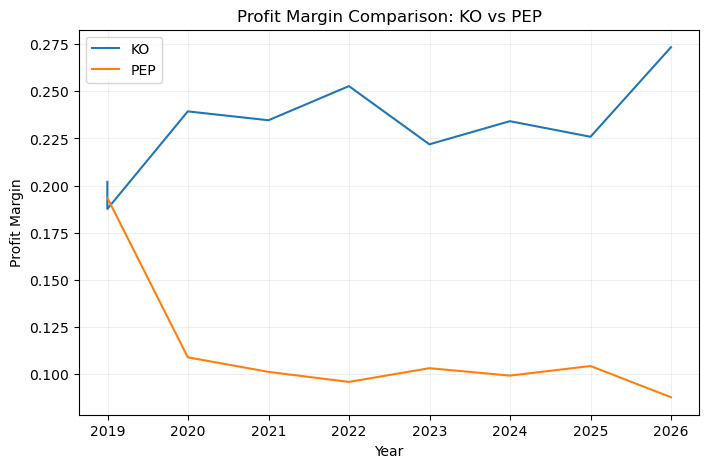

In [23]:
plt.figure(figsize=(8,5))

plt.plot(company_1_data['datadate'], company_1_data['profit_margin'], label=company_1)
plt.plot(company_2_data['datadate'], company_2_data['profit_margin'], label=company_2)

plt.title('Profit Margin Comparison: ' + company_1 + ' vs ' + company_2)
plt.xlabel('Year')
plt.ylabel('Profit Margin')
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Interpretation of Profit Margin

The chart shows the profit margin of the two selected companies over time.

Differences in profit margin indicate that the two companies vary in their ability to convert revenue into profit.

The chart also helps users observe whether profitability is stable or changes across years.

### Asset Turnover Comparison

The chart below compares the asset turnover of the selected companies over time.

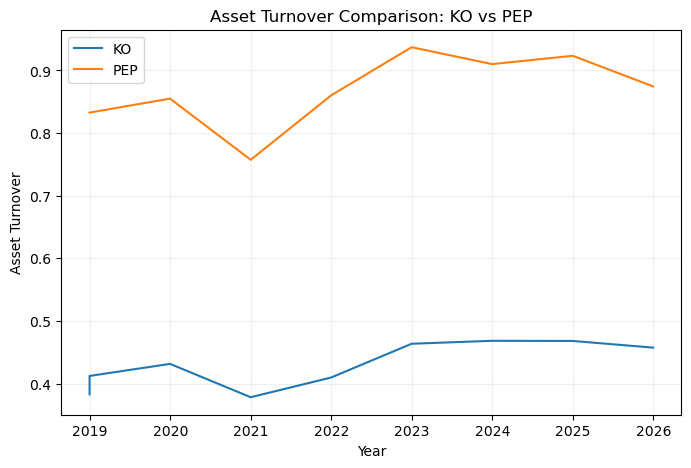

In [24]:
plt.figure(figsize=(8,5))

plt.plot(company_1_data['datadate'], company_1_data['asset_turnover'], label=company_1)
plt.plot(company_2_data['datadate'], company_2_data['asset_turnover'], label=company_2)

plt.title('Asset Turnover Comparison: ' + company_1 + ' vs ' + company_2)
plt.xlabel('Year')
plt.ylabel('Asset Turnover')
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Interpretation of Asset Turnover

The chart shows how efficiently the two selected companies use their assets to generate revenue.

Differences in asset turnover suggest different levels of operating efficiency.

The visual comparison allows users to assess whether one company uses its assets more effectively over time.

### Leverage Comparison

The chart below compares the leverage of the selected companies over time.

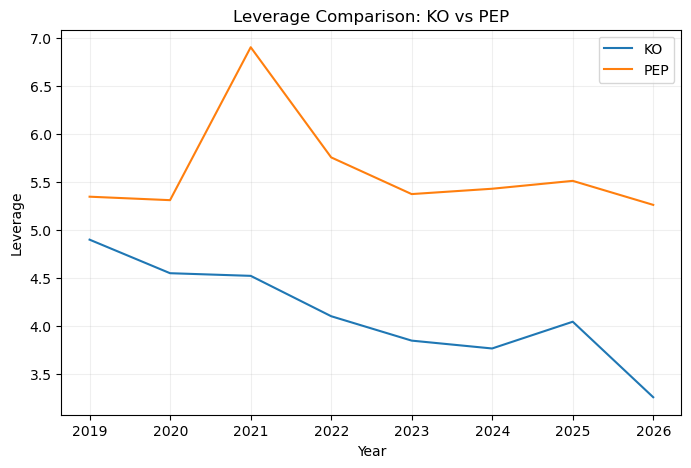

In [25]:
plt.figure(figsize=(8,5))

plt.plot(company_1_data['datadate'], company_1_data['leverage'], label=company_1)
plt.plot(company_2_data['datadate'], company_2_data['leverage'], label=company_2)

plt.title('Leverage Comparison: ' + company_1 + ' vs ' + company_2)
plt.xlabel('Year')
plt.ylabel('Leverage')
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Interpretation of Leverage

The chart shows the level of financial leverage used by the two selected companies over time.

Differences in leverage indicate that the companies may rely on different financial structures.

This comparison can help users understand whether stronger performance is associated with higher leverage.

## Step 8: Summary of Financial Ratios

In this step, the average values of each financial ratio are calculated for each company. This provides a simplified overview for comparison.

In [27]:
summary_data = selected_data.groupby('company')[['ROE', 'profit_margin', 'asset_turnover', 'leverage']].mean()

summary_data

,ROE,profit_margin,asset_turnover,leverage
company,,,,
KO,0.41089,0.230188,0.430176,4.210673
PEP,0.538178,0.111728,0.868852,5.613564


## Limitations of Average Values

The use of average values provides a simple summary of company performance over time. However, it may not fully capture variations and trends within the data.

For example, average values may hide fluctuations or changes in performance across different years. Therefore, the graphical analysis presented earlier is also important for understanding trends and stability.

## Step 9: Automated Conclusion 

Based on the average values of the financial ratios, simple rules are used to automatically generate a basic comparison between the companies.

In [28]:
# Extract values
company_1_ROE = summary_data.loc[company_1, 'ROE']
company_2_ROE = summary_data.loc[company_2, 'ROE']

company_1_margin = summary_data.loc[company_1, 'profit_margin']
company_2_margin = summary_data.loc[company_2, 'profit_margin']

company_1_turnover = summary_data.loc[company_1, 'asset_turnover']
company_2_turnover = summary_data.loc[company_2, 'asset_turnover']

company_1_leverage = summary_data.loc[company_1, 'leverage']
company_2_leverage = summary_data.loc[company_2, 'leverage']

# Rule-based comparison
if company_1_ROE > company_2_ROE:
    ROE_text = company_1 + " has a higher average ROE than " + company_2 + "."
else:
    ROE_text = company_2 + " has a higher average ROE than " + company_1 + "."

if company_1_margin > company_2_margin:
    margin_text = company_1 + " has a higher average profit margin than " + company_2 + "."
else:
    margin_text = company_2 + " has a higher average profit margin than " + company_1 + "."

if company_1_turnover > company_2_turnover:
    turnover_text = company_1 + " has a higher average asset turnover than " + company_2 + "."
else:
    turnover_text = company_2 + " has a higher average asset turnover than " + company_1 + "."

if company_1_leverage > company_2_leverage:
    leverage_text = company_1 + " has a higher average leverage than " + company_2 + "."
else:
    leverage_text = company_2 + " has a higher average leverage than " + company_1 + "."

print("Automated Conclusion")
print(ROE_text)
print(margin_text)
print(turnover_text)
print(leverage_text)

Automated Conclusion
PEP has a higher average ROE than KO.
KO has a higher average profit margin than PEP.
PEP has a higher average asset turnover than KO.
PEP has a higher average leverage than KO.


## Step 10: Automated Overall Summary

A simple overall summary is generated based on ROE comparison.

In [29]:
if company_1_ROE > company_2_ROE:
    overall_text = "Overall, " + company_1 + " shows stronger returns to shareholders."
else:
    overall_text = "Overall, " + company_2 + " shows stronger returns to shareholders."

print("Overall Summary")
print(overall_text)

Overall Summary
Overall, PEP shows stronger returns to shareholders.


## Final Interpretation

While the automated results provide a basic comparison, further interpretation is still required.

The company with stronger ROE may achieve this through different drivers, such as higher profitability, better asset efficiency, or greater leverage.

Therefore, users should interpret the results together rather than relying on one single ratio.

This demonstrates that differences in company performance are influenced by multiple factors, including profitability, efficiency, and financial structure.

## Limitations

While this workflow provides a structured and automated approach to financial ratio analysis, several limitations should be noted.

First, the analysis is based on financial data from the Compustat database, which mainly covers US listed companies. Therefore, the results may not be applicable to companies outside this dataset.

Second, the use of average values simplifies comparison but may hide important details in the data. For example, average values do not capture volatility or fluctuations over time, and may overlook upward or downward trends in performance. In addition, extreme values in certain years may distort the overall average, leading to potentially misleading conclusions.

Third, financial ratios alone do not provide a complete picture of company performance. Other factors such as market conditions, strategy, and industry characteristics are not considered in this analysis.

Finally, the automated conclusions are based on simple rule-based logic and cannot replace deeper financial analysis or professional judgement.

Future improvements could include incorporating more advanced analysis methods and expanding the range of financial indicators.

## Conclusion

This project demonstrates how Python can be used to automate financial ratio analysis and support company comparison.

The workflow allows users to efficiently analyse different companies by modifying simple input parameters, while still requiring user interpretation to fully understand the results.

In [30]:
db.close()